# **Computational Analysis of the 3D Ising Model**
### A project for *Stochastic Processes and Simulations in Natural Sciences*

------

+ Scaffidi Muta Federico
+ Porta Andrea

### *Abstract*

> In this notebook we are going to analyse the magnetic behaviour of a material under perturbations. <br>
> In particular, we treat each atom as a binary neuron, with spin variable $S_i \in \{-1, +1\}$, representing its **magnetic moment**. <br>
> Our model is a *3D* representation of the material and includes $N$ atoms, arranged in a cubic lattice of size $L$ per dimension (i.e. $N = L^3$). <br>
> We aim to identify the critical temperature marking the phase transition between **ferromagnetic** and **paramagnetic** behaviour. <br>
> The behaviour of the magnetization as a function of the temperature suggests a phase transition around $kT/J \approx 4.5$.


----

## Set up

* Since we assume a constant coupling $J$, with $J_{ij} = J$ for every pair of neighbouring sites, we can write the energy function as  
  $$E(S) = -J \sum_{\langle i,j \rangle} S_i S_j$$
   Without loss of generality, we set $J_{ij}=1$ for every pair of neighbouring sites.

* At $T = 0$, since the interaction matrix is symmetric, the dynamics becomes deterministic, as spin flips are accepted only when they produce an energy change $\Delta E < 0$. <br> The energy is then a decreasing function with respect to time. <br>
For $N$ large enough to ignore the boundaries, the minimum energy approach $E_{min}$ = $-3JN$ (different from 2D model, where it is $-2JN$).



* With $T>0$, the dynamics becomes probabilistic.<br>
We proceed using *Metropolis-Hastings* to simulate the system. <br> <br>
***Additionally***, we implement the *Wolff algorithm* [3]; *simulated tempering* [4] is discussed in Appendix A. <br><br>
In these algorithms [7], after a burn in period in which the system reaches an equilibrium, we always get to a well defined stationary distribution $\pi$ that approximates the Boltzmann's distribution of the states of the system at temperature $T$. <br>
Because the probability distribution decreases with increasing energy, the system predominantly explores low-energy states, which are statistically favored.

* Given $Si$, the magnetization of the $i_{th}$ atom, the total observed magnetization is given by 
  $$M(S) = \sum_{ i} S_i/N$$
  Since in our simulations the stationary distribution $\pi$ approximates the Boltzmann's distribution $P_B$, then the expected total magnetization is given by 
  $$E_{S \sim P_B}(M) = \int_{s \in S} M(S) P_B (S)$$

-----

## Initialise the 3D Ising model

* Before implementing any Monte Carlo dynamics, we need:

    1. **A representation of the spin configuration**  
       We store spins as a 1D array of length $N = L^3$ with values $\pm 1$.  
       A tensor view (shape $L\times L\times L$) can always be obtained via `reshape`, but the vector form simplifies indexing and allows efficient ΔE updates.

    2. **A precomputed neighbour table with periodic boundary conditions (PBC)**  
       For each site $i$, the table lists the 6 nearest neighbours under PBC. This avoids recomputing modulo arithmetic inside inner Monte Carlo loops and makes both Metropolis and Wolff updates substantially faster.

    3. **Energy evaluation**  
       We define `compute_energy`, which implements the Ising Hamiltonian  
       $$
       E = -\sum_{\langle i,j\rangle} s_i s_j .
       $$

    4. **Magnetization evaluation**  
       $$
       m = \frac{1}{N}\sum_i s_i
       $$
       is used to study the phase transition. In practice we typically work with $|m|$.

    5. **A lightweight spin-flip operator**  
       `flip_state(state, i)` flips spin $s_i$ in-place. This utility is used in Metropolis updates and in the ΔE scheme.

    6. **Deterministic initial configuration (optional)**  
       An RNG object (`np.random.default_rng(seed)`) is used to generate a reproducible random initial configuration. This isolates initialization from the stochastic Monte Carlo dynamics that follow.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Initialize a random vector S_i of spins, assuming J=1
L = 10
N = L**3

# Seed the global NumPy RNG: the Monte Carlo loops below use np.random.* directly,
# so this single call makes the whole notebook reproducible when run top to bottom.
np.random.seed(0)

rng_init = np.random.default_rng(0)
S_init_vector = rng_init.choice([-1, 1], size=N)

S_init_tensor = S_init_vector.reshape((L, L, L))

In [3]:
def build_neighbors_pbc(L: int) -> np.ndarray:
    """
    Build neighbor indices for a 3D LxLxL lattice with periodic BC.

    Returns:
        neighbors: int32 array of shape (N, 6)
                   neighbors[i, k] = index of the k-th neighbor of site i.
                   Order of neighbors:
                       0: +x, 1: -x, 2: +y, 3: -y, 4: +z, 5: -z
    """
    N = L**3
    idx = np.arange(N)
    x = idx % L
    y = (idx // L) % L
    z = idx // (L * L)

    neighbors = np.empty((N, 6), dtype=np.int32)

    # +x, -x
    xp = (x + 1) % L
    xm = (x - 1) % L
    neighbors[:, 0] = xp + L * y + L * L * z
    neighbors[:, 1] = xm + L * y + L * L * z

    # +y, -y
    yp = (y + 1) % L
    ym = (y - 1) % L
    neighbors[:, 2] = x + L * yp + L * L * z
    neighbors[:, 3] = x + L * ym + L * L * z

    # +z, -z
    zp = (z + 1) % L
    zm = (z - 1) % L
    neighbors[:, 4] = x + L * y + L * L * zp
    neighbors[:, 5] = x + L * y + L * L * zm

    return neighbors

In [4]:
# Compute energy function
def compute_energy(S: np.ndarray, neighbors: np.ndarray) -> float:
    """
    Compute Ising energy with periodic BC:

        E = - sum_{<i,j>} S_i S_j

    where the sum is over nearest neighbors, each bond counted once.
    'neighbors' must list the 6 neighbors of each site (PBC).
    """
    S = np.asarray(S, dtype=np.int8)
    E = 0.0

    # now all neighbors are valid (no -1), so we can drop the mask
    for k in range(6):
        n = neighbors[:, k]
        E -= np.sum(S * S[n])

    # every pair (i,j) is counted twice (once from i, once from j)
    return E / 2.0

# Compute magnetization function
def compute_magnetization(S: np.ndarray) -> float:
    """
    Magnetization per spin.
    S: array of spins in {+1, -1}, shape (N,).
    """
    S = np.asarray(S)
    return float(S.mean())

In [5]:
# Build neighbors table
neighbors_l10 = build_neighbors_pbc(L)

In [6]:
E_init = compute_energy(S_init_vector, neighbors_l10)
print("Initial Energy:", E_init)

# Calculate the initial magnetization
M_init = compute_magnetization(S_init_vector)
print("Initial Magnetization:", M_init)

Initial Energy: -24.0
Initial Magnetization: 0.074


In [7]:
# Flip state function
def flip_state(S_vector, index):
    S_vector[index] *= -1
    return S_vector

----

## Study of *Deterministic dynamic* for N=1000 spins
#### T = 0 comparison

Study of *Deterministic Dynamics* for an Ising System with N = 1000 Spins

In this section we examine the behaviour of the 3D Ising model under a
**zero-temperature (T = 0) Metropolis rule**, where only energy-lowering
moves are accepted. This produces a *deterministic descent dynamics*
because the update rule is:

$$
S_{t+1} =
\begin{cases}
\text{flipped configuration} & \text{if } E(S_{t+1}) < E(S_t), \\
S_t & \text{otherwise}.
\end{cases}
$$

Under this rule the energy function  
$$
f(t) = E(S_t)
$$ 
is **monotonically non-increasing**, since:

- $f(t+1) = f(t)$ only when the proposed move *increases* energy
  (and is therefore rejected),
- $f(t+1) < f(t)$ whenever a flip lowers the energy.

As a consequence, the system inevitably converges to a configuration where
**no single spin flip can reduce the energy any further**.  
Such a configuration is a **local minimum** of the Hamiltonian, not necessarily
the global ferromagnetic ground state $E = -3JN$.

Once the system enters such a stable configuration, the dynamics becomes
frozen:
- the magnetisation and the energy remain constant,
- domain walls persist if they cannot be removed by flipping a single spin,
- the final energy may lie strictly above the true ground-state energy.

This section compares this deterministic evolution with the finite-temperature
Monte Carlo dynamics studied later, where thermal fluctuations allow <br> the system
to escape local minima.

In [8]:
# Deterministic Metropolis acceptance criterion
def det_metropolis_cond(e_old, e_new):
    if e_new < e_old: 
        return True
    else:
        return False

In [9]:
def deterministic_metropolis(S_vector, neighbors, E, n_step: int):
    '''
    Simulation using "Deterministic Metropolis-Hastings"
    Parameters:
        - S_vector: initial model state
        - neighbors: (N, 6) neighbour table from build_neighbors_pbc
        - E: initial energy of the system
        - n_step: set number of steps of the algorithm
    Output:
        - e_history_det: array of energy at each step
        - m_history_det: array of magnetisation at each step
    '''

    # Initialisation
    s = S_vector.copy()
    e_old = E
    e_history_det = []
    m_history_det = []

    # Main loop
    for _ in range(n_step):

        # Pick a random spin and flip it
        i = np.random.randint(s.size)
        s = flip_state(s, i)
        
        # Compute new energy
        e_new = compute_energy(s, neighbors)
        
        # Metropolis acceptance
        if det_metropolis_cond(e_old, e_new):
            e_old = e_new
        else:
            s = flip_state(s, i)
            
        # Compute magnetisation
        m = np.abs(compute_magnetization(s))

        # Store energy and magnetization
        e_history_det.append(e_old)
        m_history_det.append(m)
        
    return e_history_det, m_history_det

In [10]:
# Parameters
N_STEP = 100000

# Initialise state
s_init = S_init_vector.copy()

# Run deterministic Metropolis-Hastings algorithm
e_history_det, m_history_det = deterministic_metropolis(s_init, neighbors_l10, E_init, n_step=N_STEP)

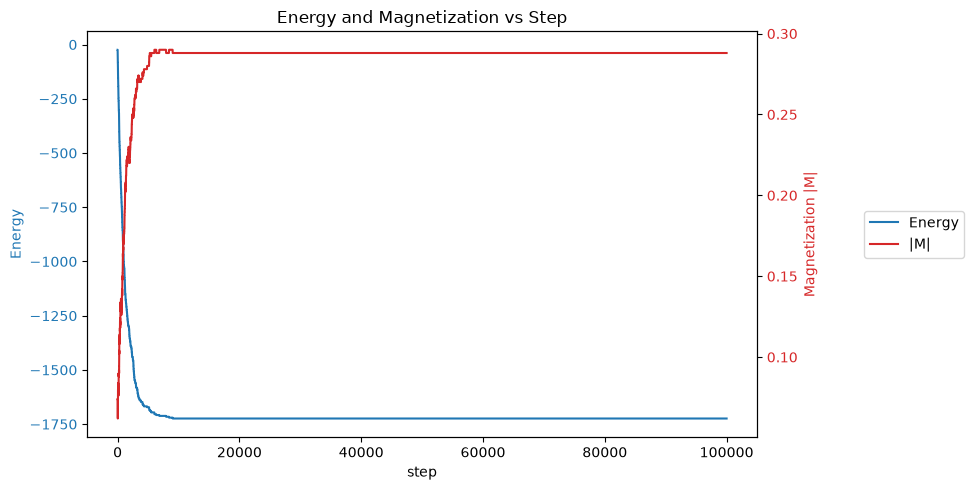

In [11]:
# Create figure and first axis (left y-axis)
fig, ax1 = plt.subplots(figsize=(10,5))

# Energy plot (left y-axis)
color_e = "tab:blue"
ax1.plot(e_history_det, color=color_e, label="Energy")
ax1.set_xlabel("step")
ax1.set_ylabel("Energy", color=color_e)
ax1.tick_params(axis="y", labelcolor=color_e)

# Create second axis sharing the same x-axis
ax2 = ax1.twinx()

# Magnetization plot (right y-axis)
color_m = "tab:red"
ax2.plot(np.abs(m_history_det), color=color_m, label="|M|")
ax2.set_ylabel("Magnetization |M|", color=color_m)
ax2.tick_params(axis="y", labelcolor=color_m)

# Collect handles/labels from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Put legend outside the axes on the right
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center left",
    bbox_to_anchor=(1.15, 0.5)   # shift legend outside
)

plt.title("Energy and Magnetization vs Step")
plt.tight_layout()
plt.show()

---

## *Metropolis-Hastings*

The Metropolis–Hastings (MH) algorithm [1, 2] is a Markov chain Monte Carlo method
used to sample from the Boltzmann distribution

$$
\pi(S) \propto e^{-\beta E(S)} ,
$$

where $E(S)$ is the Ising Hamiltonian and $\beta = 1/T$ is the inverse temperature.
The MH transition kernel is constructed so that $\pi$ is its stationary distribution
and **detailed balance** holds:

$$
\pi(S)\,P(S \to S') = \pi(S')\,P(S' \to S).
$$

For the Ising model with single–spin updates:

1. Choose a site $i$ uniformly at random.
2. Propose flipping its spin: $S_i \to -S_i$, which changes the energy by $\Delta E$.
3. Accept the flip with probability

$$
P_{\text{acc}} = \min\{1,\, e^{-\beta \Delta E}\}.
$$

Thus the transition probability for flipping spin $i$ is

$$
P(S_i \to -S_i) = \frac{1}{N} \min\bigl(1,\, e^{-\beta \Delta E}\bigr),
$$

where $N = L^3$ is the total number of spins.

* The total number of Metropolis steps at each temperature was set to
  $N_{\text{steps}} = n_{\text{sweeps}} \times L^3$, ensuring that the
  dynamics performs several thousand full sweeps of the lattice. This is
  necessary because Metropolis updates are local and decorrelate the system
  very slowly, especially near $T_c$, where autocorrelation times diverge.

This update rule guarantees that the Markov chain converges to the Boltzmann
distribution at temperature $T$, enabling the numerical study of thermodynamic
quantities such as energy, magnetisation, and their fluctuations.

In [12]:
def metropolis_sweeps(
    S_vector: np.ndarray,
    neighbors: np.ndarray,
    temp: float,
    n_sweeps: int,
    burn_in_sweeps: int = 0,
    measure_interval: int = 1,
):
    """
    Metropolis simulation using local ΔE and sweeps.

    Parameters
    ----------
    S_vector : 1D array of shape (N,)
        Initial spin configuration (±1). Not modified: a copy is evolved.
    neighbors : array of shape (N, 6)
        Neighbor table from build_neighbors_pbc(L).
    temp : float
        Temperature T.
    n_sweeps : int
        Number of measurement sweeps (after burn-in).
    burn_in_sweeps : int, optional
        Number of burn-in sweeps (no measurements), default 0.
    measure_interval : int, optional
        Record one measurement every `measure_interval` sweeps
        after burn-in. Default 1 (measure every sweep).

    Returns
    -------
    e_samples : 1D array
        Recorded energies (one per measurement sweep).
    m_samples : 1D array
        Recorded |magnetization| per spin.
    S : 1D array
        Final configuration (a new array; the input is left untouched).
    e_current : float
        Final energy corresponding to S_vector.
    """
    
    S = S_vector.copy()  # work on a copy so the caller's array is not modified
    N = S.size
    beta = 1.0 / temp

    # initial energy (one O(N) call per run)
    e_current = compute_energy(S, neighbors)

    e_samples = []
    m_samples = []

    total_sweeps = burn_in_sweeps + n_sweeps

    for sweep in range(total_sweeps):
        # one sweep = N attempted single-spin flips
        for _ in range(N):
            i = np.random.randint(N)
            si = S[i]
            # local field from the 6 neighbours
            neigh = neighbors[i]
            h_loc = S[neigh].sum()
            # ΔE = 2 s_i * (sum_j s_j)
            dE = 2.0 * si * h_loc

            if dE <= 0.0:
                # always accept energy-lowering move
                S[i] = -si
                e_current += dE
            else:
                # accept with Metropolis prob
                if np.random.random() < np.exp(-beta * dE):
                    S[i] = -si
                    e_current += dE
                # else reject: do nothing

        # after this sweep, maybe record
        if sweep >= burn_in_sweeps:
            if (sweep - burn_in_sweeps) % measure_interval == 0:
                e_samples.append(e_current)
                m_samples.append(abs(compute_magnetization(S)))

    return np.array(e_samples), np.array(m_samples), S, e_current

In [13]:
# Parameters
TEMP = 2.9
BURN_SWEEPS   = 0   # burn-in sweeps per T (set to zero to see all steps)
MEAS_SWEEPS   = 1000   # measurement sweeps per T
MEAS_INTERVAL = 5     # record every 5 sweeps 

# Initialise state
s_init = S_init_vector.copy()

# Run Metropolis-Hastings
e_samples, m_samples, state, E_size = metropolis_sweeps(
            S_vector=s_init,
            neighbors=neighbors_l10,
            temp=TEMP,
            n_sweeps=MEAS_SWEEPS,
            burn_in_sweeps=BURN_SWEEPS,
            measure_interval=MEAS_INTERVAL,
        )

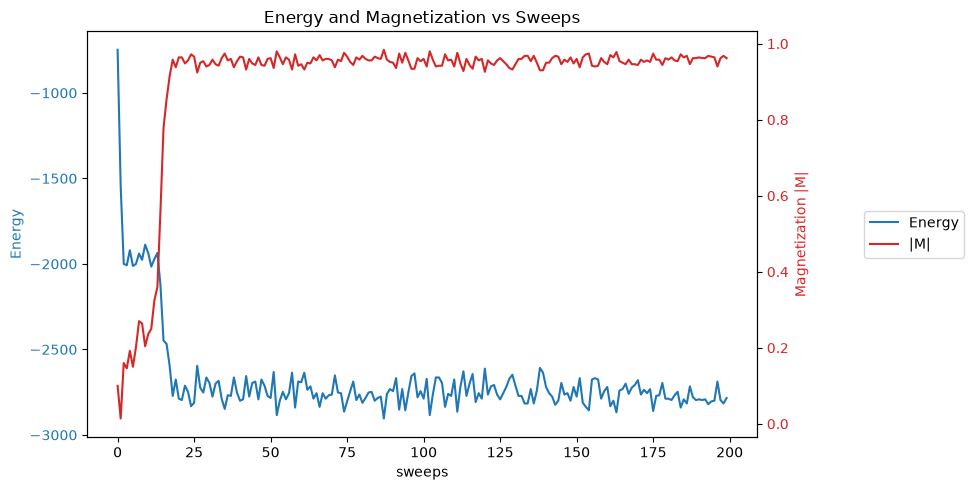

In [14]:
# Create figure and first axis (left y-axis)
fig, ax1 = plt.subplots(figsize=(10,5))

# Energy plot (left y-axis)
color_e = "tab:blue"
ax1.plot(e_samples, color=color_e, label="Energy")
ax1.set_xlabel("sweeps")
ax1.set_ylabel("Energy", color=color_e)
ax1.tick_params(axis="y", labelcolor=color_e)

# Create second axis sharing the same x-axis
ax2 = ax1.twinx()

# Magnetization plot (right y-axis)
color_m = "tab:red"
ax2.plot(np.abs(m_samples), color=color_m, label="|M|")
ax2.set_ylabel("Magnetization |M|", color=color_m)
ax2.tick_params(axis="y", labelcolor=color_m)

# Collect handles/labels from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Put legend outside the axes on the right
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center left",
    bbox_to_anchor=(1.15, 0.5)   # shift legend outside
)

plt.title("Energy and Magnetization vs Sweeps")
plt.tight_layout()
plt.show()

* Although the **Metropolis–Hastings** algorithm correctly converges to the Boltzmann distribution in theory, it exhibits clear limitations in practice. At finite temperature, the energy trajectory shows large autocorrelation times, and the approach to equilibrium is extremely slow.

  Even though the KL divergence $D_{\mathrm{KL}}(P_B \,\|\, P_M(t))$ decreases
  over time, the chain mixes so slowly that meaningful sampling from $P_B$
  becomes impractical for systems of moderate size.

* To overcome this, we can implement the **Wolff algorithm**, that is more efficient near the critical region, where Metropolis-Hastings suffers the most from critical slowing-down.

* As a possible extension, discussed in Appendix A, **Simulated Tempering** [4] is an MCMC technique designed to accelerate
  mixing by allowing the chain to move between temperatures. It is not implemented here.

Now, we test Metropolis-Hastings algorithm for multiple instances, where we compute magnetisation against temperature, for different number of atoms $N$.

In [15]:
'''
Phase transition study
Parameters:
    - sizes: range of sizes to test
    - TEMPS: range of temperatures (below/around/above critical value)
    - BURN_SWEEPS: burn-in sweeps per temperature
    - MEAS_SWEEPS: measurement sweeps per temperature
    - MEAS_INTERVAL: record one sample every MEAS_INTERVAL sweeps
Output:
    - e_mean: array of average system energy against target temperature, for each size
    - m_mean: array of average system magnetisation against temperature target, for each size
'''

sizes = [6, 8, 10]

T_low  = np.linspace(0.5, 3.5, 11)
T_crit = np.linspace(3.8, 4.7, 11)
T_high = np.linspace(5.0, 8.0, 11)
TEMPS  = np.concatenate([T_low, T_crit, T_high])
TEMPS = np.sort(TEMPS)

BURN_SWEEPS   = 400   # burn-in sweeps per T
MEAS_SWEEPS   = 1000   # measurement sweeps per T
MEAS_INTERVAL = 5     # record every 5 sweeps

e_mean = []
m_mean = []

rng_size = np.random.default_rng(0)

for L in sizes:
    N = L**3
    neighbors_size = build_neighbors_pbc(L)

    # initial random configuration for this size
    S_size_vector = rng_size.choice([-1, 1], size=N)

    e_mean_Ts = []
    m_mean_Ts = []

    # start from this config and warm–start across temperatures
    state = S_size_vector.copy()

    for T in TEMPS:
        e_samples, m_samples, state, E_size = metropolis_sweeps(
            S_vector=state,
            neighbors=neighbors_size,
            temp=T,
            n_sweeps=MEAS_SWEEPS,
            burn_in_sweeps=BURN_SWEEPS,
            measure_interval=MEAS_INTERVAL,
        )

        e_mean_Ts.append(e_samples.mean())
        m_mean_Ts.append(m_samples.mean())

        print(f"End of temp {T:.2f} for size L={L}")

    e_mean.append(e_mean_Ts)
    m_mean.append(m_mean_Ts)
    print(f"End of size L={L}")

e_mean = np.array(e_mean)
m_mean = np.array(m_mean)

End of temp 0.50 for size L=6
End of temp 0.80 for size L=6
End of temp 1.10 for size L=6
End of temp 1.40 for size L=6
End of temp 1.70 for size L=6
End of temp 2.00 for size L=6
End of temp 2.30 for size L=6
End of temp 2.60 for size L=6
End of temp 2.90 for size L=6
End of temp 3.20 for size L=6
End of temp 3.50 for size L=6
End of temp 3.80 for size L=6
End of temp 3.89 for size L=6
End of temp 3.98 for size L=6
End of temp 4.07 for size L=6
End of temp 4.16 for size L=6
End of temp 4.25 for size L=6
End of temp 4.34 for size L=6
End of temp 4.43 for size L=6
End of temp 4.52 for size L=6
End of temp 4.61 for size L=6
End of temp 4.70 for size L=6
End of temp 5.00 for size L=6
End of temp 5.30 for size L=6
End of temp 5.60 for size L=6
End of temp 5.90 for size L=6
End of temp 6.20 for size L=6
End of temp 6.50 for size L=6
End of temp 6.80 for size L=6
End of temp 7.10 for size L=6
End of temp 7.40 for size L=6
End of temp 7.70 for size L=6
End of temp 8.00 for size L=6
End of siz

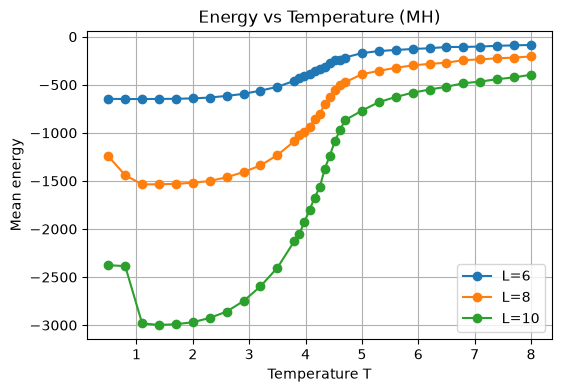

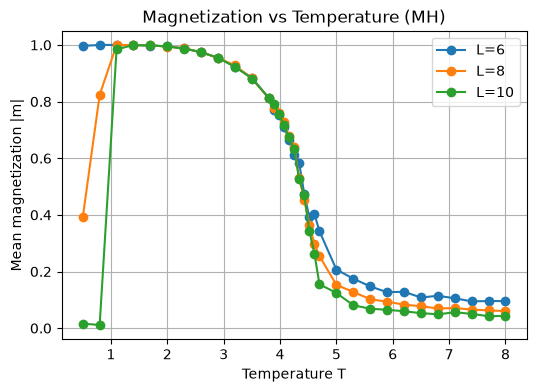

In [16]:
e_mean = np.array(e_mean)
m_mean = np.array(m_mean)

plt.figure(figsize=(6,4))

n_runs = e_mean.shape[0]

for r, l in zip(range(n_runs), sizes):
    plt.plot(TEMPS, e_mean[r], marker='o', linestyle='-', label=f"L={l}")

plt.xlabel("Temperature T")
plt.ylabel("Mean energy")
plt.title("Energy vs Temperature (MH)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))

n_runs = m_mean.shape[0]

for r, l in zip(range(n_runs), sizes):
    plt.plot(TEMPS, np.abs(m_mean[r]), marker='o', linestyle='-', label=f"L={l}")

plt.xlabel("Temperature T")
plt.ylabel("Mean magnetization |m|")
plt.title("Magnetization vs Temperature (MH)")
plt.legend()
plt.grid(True)
plt.show()

* The hypothesis $T_c \approx 4.5$ is clearly supported by our results:  
  the transition becomes evident in the temperature window near $T_c$, and all system sizes exhibit the expected finite–size rounding.

* Some noise in the magnetisation and energy curves is expected.
  For each temperature we performed only **one Monte Carlo run**, and the
  averages were computed from the time series recorded after a burn–in period.
  Since Metropolis updates have **strong autocorrelations** between consecutive
  configurations, these samples are not statistically independent, and the
  noise level could remain high even for long trajectories.

* To mitigate these effects we were forced to use a **large number of Metropolis
  sweeps per temperature**, simply to obtain a reasonable number of effectively
  independent samples.

* This motivates the comparison with the **Wolff algorithm**, whose
  cluster updates drastically reduce autocorrelation times and produce smooth,
  well-equilibrated estimates with far fewer Monte Carlo steps.

----

## *Wolff algorithm*

The **Wolff algorithm** [3] is a cluster Monte Carlo method designed to sample from
the Boltzmann distribution
$$
\pi(S) \propto e^{-\beta E(S)}
$$
while avoiding the critical slowing-down that affects single–spin Metropolis
updates. It constructs a Markov chain that satisfies **detailed balance** and
has $\pi$ as its stationary distribution, but uses *non-local* cluster flips
instead of local spin updates.

The update proceeds as follows:

1. **Choose a seed spin** $i$ uniformly at random from the lattice.

2. **Grow a cluster** by recursively adding nearest neighbours $j$ of $i$ that are *aligned* with the seed spin ($S_j = S_i$).  
   Each aligned neighbour is added to the cluster with probability
   $$
   P_{\mathrm{add}} = 1 - e^{-2\beta},
   $$
   derived by imposing the detailed balance condition.

3. **Flip the entire cluster** simultaneously:
   $$
   S_k \rightarrow -S_k \quad \text{for all } k \text{ in the cluster}.
   $$

This update is accepted with probability 1 because the construction of the
cluster ensures detailed balance.

A key feature of the algorithm is that the **average cluster size diverges near
the critical temperature**, allowing the chain to perform macroscopic moves
that dramatically reduce autocorrelation times. This leads to much faster
convergence to equilibrium compared to the Metropolis algorithm, especially
in the critical region.

In [17]:
def wolff_step(S_vec: np.ndarray, neighbors: np.ndarray, beta: float):
    """
    One Wolff cluster update for 3D Ising (J=1, PBC), vector version with ΔE.

    Parameters
    ----------
    S_vec    : 1D array (N,), spins ±1. Modified in place.
    neighbors: int array (N, 6), neighbor indices (PBC).
    beta     : float, inverse temperature 1/T.

    Returns
    -------
    dE    : float
        Energy change E_new - E_old.
    m_new : float
        Magnetization per spin after the flip.
    """
    N = S_vec.size
    P_add = 1.0 - np.exp(-2.0 * beta)

    # 1) choose seed
    i0 = np.random.randint(N)
    spin0 = S_vec[i0]

    in_cluster = np.zeros(N, dtype=bool)
    in_cluster[i0] = True
    stack = [i0]

    # 2) grow cluster
    while stack:
        i = stack.pop()
        for j in neighbors[i]:
            if (not in_cluster[j]) and (S_vec[j] == spin0):
                if np.random.random() < P_add:
                    in_cluster[j] = True
                    stack.append(j)

    # 3) compute ΔE from boundary bonds
    dE = 0.0
    cluster_indices = np.nonzero(in_cluster)[0]
    for i in cluster_indices:
        s_i = S_vec[i]
        for j in neighbors[i]:
            if not in_cluster[j]:
                dE += 2.0 * s_i * S_vec[j]

    # 4) flip cluster
    S_vec[in_cluster] *= -1
    m_new = float(S_vec.mean())

    return dE, m_new

In [18]:
def wolff_run(
    S_vec: np.ndarray,
    neighbors: np.ndarray,
    T: float,
    n_steps: int,
    burn_in: int = 0,
):
    """
    Run Wolff dynamics with ΔE update, measure E and |M|.

    Parameters
    ----------
    S_vec    : 1D array (N,), spins ±1. Modified in place.
    neighbors: int array (N,6)
    T        : temperature
    n_steps  : number of recorded Wolff steps (after burn-in)
    burn_in  : number of initial Wolff steps to discard

    Returns
    -------
    E_hist : 1D array of energies
    M_hist : 1D array of |magnetization|
    S_vec  : final configuration
    """
    beta = 1.0 / T
    N = S_vec.size

    # initial energy once (O(N))
    E_current = compute_energy(S_vec, neighbors)

    # burn-in
    for _ in range(burn_in):
        dE, m_new = wolff_step(S_vec, neighbors, beta)
        E_current += dE

    E_hist = []
    M_hist = []

    for _ in range(n_steps):
        dE, m_new = wolff_step(S_vec, neighbors, beta)
        E_current += dE
        E_hist.append(E_current)
        M_hist.append(abs(m_new))

    return np.array(E_hist), np.array(M_hist), S_vec

In [19]:
# The phase-transition loop above rebinds L and N; reset them to the L = 10 lattice
# whose neighbour table (neighbors_l10) was built in the setup section.
L = 10
N = L**3

S_vec = np.ones(N, dtype=int)  # ordered initial condition

T = 2.9
burn_in = 2000
n_steps = 5000

E_hist_w, M_hist_w, S_final = wolff_run(
    S_vec=S_vec,
    neighbors=neighbors_l10,
    T=T,
    n_steps=n_steps,
    burn_in=burn_in,
)

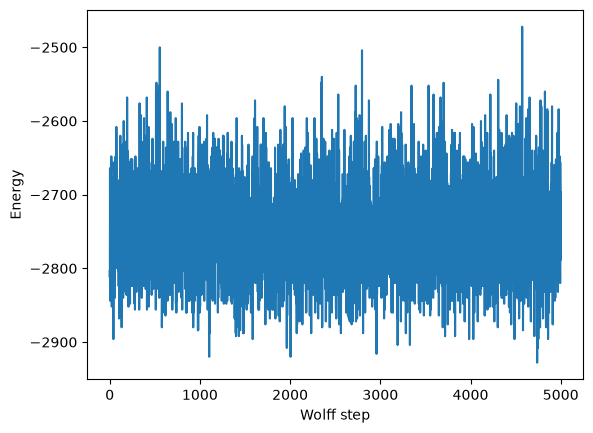

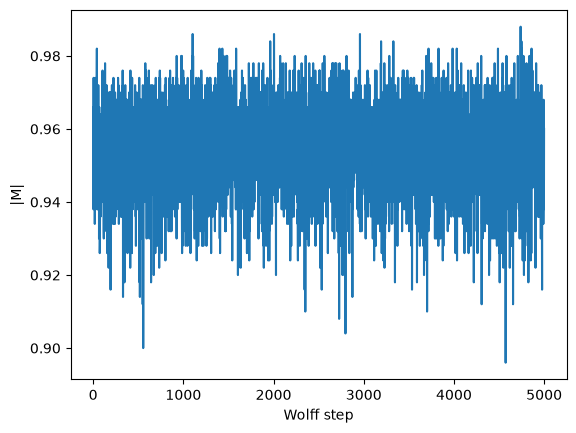

In [20]:
plt.figure()
plt.plot(E_hist_w)
plt.xlabel("Wolff step")
plt.ylabel("Energy")

plt.figure()
plt.plot(M_hist_w)
plt.xlabel("Wolff step")
plt.ylabel("|M|")
plt.show()

* The previous plots comes from $T=2.9$, a temperature contined between 0 and the critical ones.
Even if the behaviour seems already chaotic, the regime is completely in line with the standard *Wolff* dynamic, and, for such a reason, it also explores many different states and energy levels much faster than *Metropolis-Hastings*.

* This behaviour matches the theoretical expectations.
  When starting from a random configuration at low temperature, the probability
  of adding an aligned neighbour is
  $$
  P_{\mathrm{add}} = 1 - e^{-2\beta},
  $$
  which is extremely close to 1 for $T \approx 0$.  
  As a consequence, once a seed spin is chosen, the cluster typically expands
  through essentially the entire aligned domain, making it very unlikely for a
  cluster to remain small during the first iterations.

* In contrast, at **high temperature**, spin correlations decay rapidly and
  neighbouring spins are unlikely to be aligned. In this regime the Wolff clusters
  have average size $O(1)$, and the algorithm behaves similarly to a
  single–spin update.

* On the other hand, at **low temperature**, large domains dominate the configuration and the
  Wolff clusters become extensive, with typical size $O(N)$. This produces
  the large energy and magnetisation jumps seen in the time–series plots.

* At the **critical temperature** $T_c \approx 4.5115$ [5], the system exhibits
  long-range correlations, and the distribution of cluster sizes follows a
  broad, scale-free law. The average cluster size scales as
  $$
  \langle |C| \rangle = O(L^{2.48}),
  $$
  (the exponent being the fractal dimension of critical Fortuin–Kasteleyn clusters [6]) which explains why the Wolff algorithm eliminates critical slowing-down so effectively.

To empirically investigate such behavior of the algorithm, we compute the average magnetisation against different temperature values, for different sizes of the system.

In [21]:
'''
Phase transition study
Parameters:
    - sizes: range of sizes to test
    - TEMPS: range of temperatures (below/around/above critical value)
    - BURN_STEPS: burn-in time
    - MEAS_STEPS: measuring time
Output:
    - e_mean: array of average system energy against target temperature, for each size
    - m_mean: array of average system magnetisation against temperature target, for each size
'''

sizes = [6, 8, 10]

T_low  = np.linspace(0.5, 3.5, 11)
T_high = np.linspace(5.0, 8.0, 11)
T_crit = np.linspace(4.2, 4.8, 11)
TEMPS  = np.concatenate([T_low, T_crit, T_high])
# optional: TEMPS = np.sort(TEMPS)

BURN_STEPS = 2000   # Wolff cluster flips discarded as burn-in per T
MEAS_STEPS = 5000   # Wolff cluster flips recorded per T

e_mean = []
m_mean = []

for L in sizes:
    N = L**3
    print(f"\n=== Size L = {L} ===")

    # Build neighbors once for this size
    neighbors_size = build_neighbors_pbc(L)

    # Start from an ordered configuration
    S_size_vector = np.ones(N, dtype=int)

    e_mean_Ts = []
    m_mean_Ts = []

    # Warm-start: reuse final configuration across temperatures
    state = S_size_vector.copy()

    for temp in TEMPS:
        # Run Wolff with burn-in + measurement
        E_hist, M_hist, state = wolff_run(
            S_vec=state,
            neighbors=neighbors_size,
            T=temp,
            n_steps=MEAS_STEPS,
            burn_in=BURN_STEPS,
        )

        e_mean_Ts.append(E_hist.mean())
        m_mean_Ts.append(M_hist.mean())

        print(f"End of T = {temp:.3f} for L = {L}")

    e_mean.append(e_mean_Ts)
    m_mean.append(m_mean_Ts)
    print(f"End of size L = {L}")

e_mean = np.array(e_mean)
m_mean = np.array(m_mean)



=== Size L = 6 ===
End of T = 0.500 for L = 6
End of T = 0.800 for L = 6
End of T = 1.100 for L = 6
End of T = 1.400 for L = 6
End of T = 1.700 for L = 6
End of T = 2.000 for L = 6
End of T = 2.300 for L = 6
End of T = 2.600 for L = 6
End of T = 2.900 for L = 6
End of T = 3.200 for L = 6
End of T = 3.500 for L = 6
End of T = 4.200 for L = 6
End of T = 4.260 for L = 6
End of T = 4.320 for L = 6
End of T = 4.380 for L = 6
End of T = 4.440 for L = 6
End of T = 4.500 for L = 6
End of T = 4.560 for L = 6
End of T = 4.620 for L = 6
End of T = 4.680 for L = 6
End of T = 4.740 for L = 6
End of T = 4.800 for L = 6
End of T = 5.000 for L = 6
End of T = 5.300 for L = 6
End of T = 5.600 for L = 6
End of T = 5.900 for L = 6
End of T = 6.200 for L = 6
End of T = 6.500 for L = 6
End of T = 6.800 for L = 6
End of T = 7.100 for L = 6
End of T = 7.400 for L = 6
End of T = 7.700 for L = 6
End of T = 8.000 for L = 6
End of size L = 6

=== Size L = 8 ===
End of T = 0.500 for L = 8
End of T = 0.800 for L =

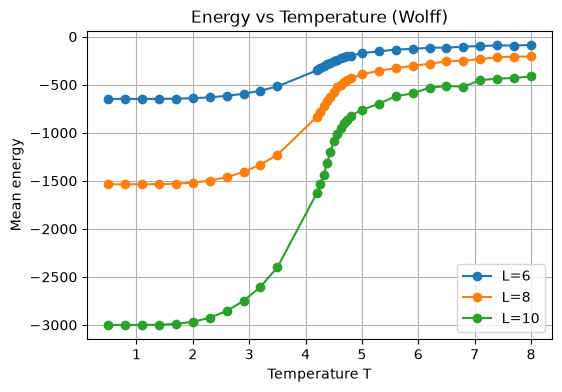

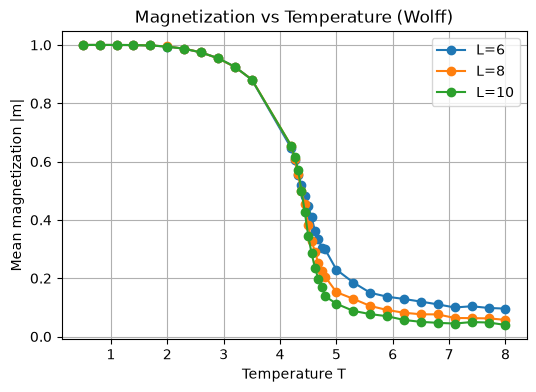

In [22]:
plt.figure(figsize=(6,4))
for idx, L in enumerate(sizes):
    plt.plot(TEMPS, e_mean[idx], marker='o', linestyle='-', label=f"L={L}")
plt.xlabel("Temperature T")
plt.ylabel("Mean energy")
plt.title("Energy vs Temperature (Wolff)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
for idx, L in enumerate(sizes):
    plt.plot(TEMPS, m_mean[idx], marker='o', linestyle='-', label=f"L={L}")
plt.xlabel("Temperature T")
plt.ylabel("Mean magnetization |m|")
plt.title("Magnetization vs Temperature (Wolff)")
plt.legend()
plt.grid(True)
plt.show()

Although the Wolff algorithm converges in far fewer Monte Carlo steps than Metropolis, each Wolff update is substantially more expensive. A Metropolis update flips only one spin and costs $O(1)$, while a Wolff update grows a cluster whose size is $O(1)$ at high temperature, $O(N)$ at low temperature, and $O(L^{2.48})$ near the critical point [6]. As a result, a single Wolff update may require touching thousands of spins.

Thus Wolff achieves much faster *statistical* convergence (independent samples and short autocorrelation times), but its *raw computational cost per update* is higher, which explains why the overall runtime can exceed that of Metropolis despite requiring far fewer iterations. E.g., at each temperature for $L = 10$, Metropolis-Hastings attempts $(400 + 1000) \times 10^3 = 1.4 \times 10^6$ single-spin flips, while Wolff performs $2000 + 5000 = 7000$ cluster flips.

----

## *Conclusions*

In this work we implemented and compared Monte Carlo methods for sampling the
3D Ising model, with the goal of understanding both the numerical behaviour of
the algorithms and the physical properties of the system, in particular regarding average magnetisation v. temperature. Our main focus was on
the **Metropolis–Hastings** algorithm and the
**Wolff algorithm**.

**Metropolis–Hastings** provides a correct sampler for the Boltzmann distribution,
but because its updates are strictly local, the dynamics mixes very slowly near
the critical point. Long autocorrelation times force the use of many sweeps per
temperature to obtain statistically reliable estimates. This behaviour becomes
more pronounced as the system size increases.

The **Wolff algorithm**, by contrast, performs non-local updates by flipping
correlated spin clusters. Cluster sizes adapt automatically to the correlation
length of the system, becoming extensive at low temperature and exhibiting
critical scaling near $T_c$. As a result, Wolff essentially removes critical
slowing-down: only a small number of cluster updates is needed to reach
equilibrium. This makes Wolff the preferred method
for studying the phase transition.

Across all tested lattice sizes, the simulations consistently show a sharp drop
in magnetisation around  
$$
T_c \approx 4.5,
$$
confirming the known critical temperature of the 3D Ising model [5]. The transition
becomes increasingly sharp for larger $L$, in agreement with finite-size
scaling theory.

The **Simulated Tempering** discussion in Appendix A illustrates the
extended-ensemble strategy of allowing the Markov chain to move between
temperatures. Although powerful in general, ST is not necessary for the Ising
model when the Wolff algorithm is available, since Wolff already achieves fast
decorrelation even at criticality.

Overall, this project demonstrates:

- how local and cluster-based Monte Carlo methods differ in efficiency,
- how algorithmic design influences equilibration and sampling accuracy,
- and how numerical experiments recover the qualitative and quantitative features
  of the 3D Ising phase transition.

The techniques developed here provide a solid foundation for further studies,
including finite-size scaling, Binder cumulants, susceptibility peaks, or
comparisons with other extended-ensemble methods.

----

## *Appendices*

### Appendix A — Possible extension: Simulated Tempering

Although the Wolff algorithm already provides extremely efficient sampling for
the 3D Ising model, an interesting extension is the implementation of
**Simulated Tempering (ST)**, an extended-ensemble Monte Carlo method designed to
accelerate mixing in systems with rugged free-energy landscapes.

In Simulated Tempering [4], the Markov chain evolves not only in the space of spin
configurations $S$, but also in a discrete set of temperatures
$\{T_0, T_1, \ldots, T_K\}$. At each step, the algorithm either performs a
Metropolis update at the current temperature or proposes a move to a neighbouring
temperature. The joint target distribution is

$$
\Pi(S, k) \propto e^{-\beta_k E(S) + g_k},
$$

where the bias terms $g_k$ are chosen so that the marginal distribution over
temperature indices $k$ is approximately flat. When this condition is met, the
chain performs a random walk in temperature space: it occasionally rises to high
temperatures, where energy barriers are easily crossed, and later cools back down
to the target region.

**Potential benefits of ST in the context of the Ising model include:**

- **Efficient barrier crossing** at low temperatures, where local Metropolis moves
  become ineffective due to metastability.
- **Simultaneous sampling at multiple temperatures**, allowing the construction of
  thermodynamic curves (e.g., $ \langle E \rangle(T) $, $ \langle |M| \rangle(T) $)
  within a single simulation.
- **Insight into free-energy structure**, since the temperature random walk
  reveals how the chain navigates between ordered and disordered phases.
- **A useful comparison point** with the Wolff algorithm: while Wolff eliminates
  critical slowing-down using non-local updates, Simulated Tempering achieves
  improved mixing by expanding the state space rather than altering the update
  mechanism.

Even though ST is not required for the Ising model thanks to the excellent
performance of cluster algorithms, implementing it provides valuable experience
with extended-ensemble techniques and opens the door to studying more complex
systems where cluster methods are not applicable.

----

### Appendix B — Simulation parameters

All values are the ones set in the code cells above. NumPy's global RNG is seeded once with `np.random.seed(0)`; initial random configurations use `np.random.default_rng(0)`.

| Experiment | $L$ | Initial state | $T$ | Burn-in | Measured | Sampling |
| --- | --- | --- | --- | --- | --- | --- |
| Deterministic descent | 10 | random (seed 0) | 0 | — | $10^5$ single-flip attempts | every step |
| Metropolis, fixed $T$ | 10 | random (seed 0) | 2.9 | 0 sweeps | 1000 sweeps | every 5 sweeps |
| Metropolis, $T$-sweep | 6, 8, 10 | random (seed 0), warm-started across $T$ | 33 values: 11 in $[0.5, 3.5]$, 11 in $[3.8, 4.7]$, 11 in $[5.0, 8.0]$ | 400 sweeps | 1000 sweeps | every 5 sweeps |
| Wolff, fixed $T$ | 10 | all spins $+1$ | 2.9 | 2000 cluster flips | 5000 cluster flips | every flip |
| Wolff, $T$-sweep | 6, 8, 10 | all spins $+1$, warm-started across $T$ | 33 values: 11 in $[0.5, 3.5]$, 11 in $[4.2, 4.8]$, 11 in $[5.0, 8.0]$ | 2000 cluster flips | 5000 cluster flips | every flip |

One sweep is $N = L^3$ attempted single-spin flips. Throughout, $J = 1$ and $k_B = 1$, so $T$ is in units of $J/k_B$.

----

## *Bibliography*

1. N. Metropolis, A. W. Rosenbluth, M. N. Rosenbluth, A. H. Teller, E. Teller, *Equation of State Calculations by Fast Computing Machines*, J. Chem. Phys. **21**, 1087–1092 (1953). [doi:10.1063/1.1699114](https://doi.org/10.1063/1.1699114)
2. W. K. Hastings, *Monte Carlo Sampling Methods Using Markov Chains and Their Applications*, Biometrika **57**(1), 97–109 (1970). [doi:10.1093/biomet/57.1.97](https://doi.org/10.1093/biomet/57.1.97)
3. U. Wolff, *Collective Monte Carlo Updating for Spin Systems*, Phys. Rev. Lett. **62**, 361 (1989). [doi:10.1103/PhysRevLett.62.361](https://doi.org/10.1103/PhysRevLett.62.361)
4. E. Marinari, G. Parisi, *Simulated Tempering: A New Monte Carlo Scheme*, Europhys. Lett. **19**(6), 451–458 (1992). [doi:10.1209/0295-5075/19/6/002](https://doi.org/10.1209/0295-5075/19/6/002)
5. A. M. Ferrenberg, J. Xu, D. P. Landau, *Pushing the Limits of Monte Carlo Simulations for the Three-Dimensional Ising Model*, Phys. Rev. E **97**, 043301 (2018). [doi:10.1103/PhysRevE.97.043301](https://doi.org/10.1103/PhysRevE.97.043301) — reports $K_c = 0.221\,654\,626(5)$, i.e. $T_c = 1/K_c \approx 4.5115$.
6. P. Hou, S. Fang, J. Wang, H. Hu, Y. Deng, *Geometric Properties of the Fortuin–Kasteleyn Representation of the Ising Model*, Phys. Rev. E **99**, 042150 (2019). [doi:10.1103/PhysRevE.99.042150](https://doi.org/10.1103/PhysRevE.99.042150) — the fractal dimension of critical FK clusters equals the magnetic exponent $y_h = (d + 2 - \eta)/2$.
7. M. E. J. Newman, G. T. Barkema, *Monte Carlo Methods in Statistical Physics*, Oxford University Press (1999).